In [57]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

import sys
sys.path.insert(0, '/cosma/home/dp004/dc-zhan5')
import MyHaloPS as ps
import importlib
importlib.reload(ps)
import pickle
import scipy


from scipy.optimize import curve_fit
import seaborn as sns
palette_tab10 = sns.color_palette("colorblind", 10)

In [7]:
plt.rcParams["xtick.direction"] = "in"
plt.rcParams["ytick.direction"] = "in"
plt.rc("font", family="STIXGeneral", size=18)
plt.rcParams["mathtext.fontset"] = "stix"
plt.rcParams['figure.figsize'] = (2*10/3, 4)
plt.rcParams["legend.frameon"] = False


plt.rcParams["xtick.major.size"] = 5
plt.rcParams["ytick.major.size"] = 5
plt.rcParams["ytick.minor.visible"] = True
plt.rcParams["xtick.minor.visible"] = True
plt.rcParams["xtick.top"] = True
plt.rcParams["ytick.right"] = True
plt.rcParams["lines.linewidth"] = 2

In [8]:
boxsize = 205

In [17]:

odir = "../ps_data"
with open(f"{odir}/snap40/mvir/ps-intensity-gal_logM10.pickle", "rb") as f:
    Pk_mean_gal10 = pickle.load(f)
    Pk_gal10 = pickle.load(f)
print("shotnoise", Pk_gal10.attrs["shotnoise"])

shotnoise 130.52360745197086


In [18]:
odir = "../ps_data"
with open(f"{odir}/snap40/mvir/ps-intensity-sum_logM10.pickle", "rb") as f:
    Pk_mean_gal10 = pickle.load(f)
    Pk_sum10 = pickle.load(f)

In [49]:
iend = 700
ks = Pk_gal10["k"][:iend]

coef = ks**3 / (2 * np.pi **2)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


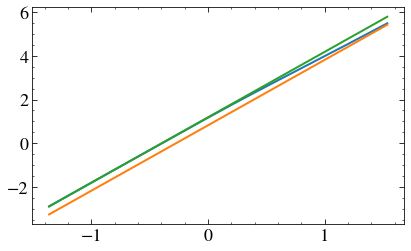

In [40]:
plt.plot(np.log10(ks), np.log10(coef*(Pk_gal10["power"][:iend]-(Pk_sum10["power"][:iend]-Pk_sum10.attrs["shotnoise"]) )))
plt.plot(np.log10(ks), np.log10(coef*Pk_gal10.attrs["shotnoise"]))
plt.plot(np.log10(ks), np.log10(coef*Pk_sum10.attrs["shotnoise"]))

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


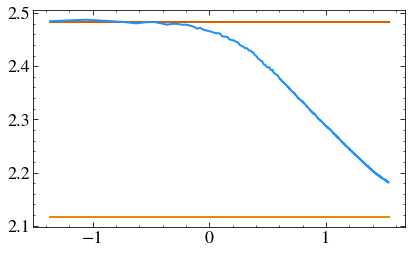

In [64]:
plt.plot(np.log10(ks), np.log10([Pk_gal10.attrs["shotnoise"]]*len(ks)), c=palette_tab10[1])
plt.plot(np.log10(ks), np.log10([Pk_sum10.attrs["shotnoise"]]*len(ks)), c=palette_tab10[3])
plt.plot(np.log10(ks), np.log10((Pk_gal10["power"][:iend]-(Pk_sum10["power"][:iend]-Pk_sum10.attrs["shotnoise"]))),c="DodgerBlue")


/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


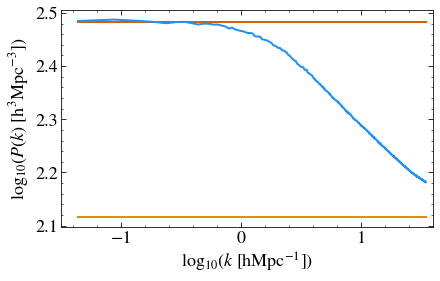

In [85]:
plt.plot(np.log10(ks), np.log10([Pk_gal10.attrs["shotnoise"]]*len(ks)), c=palette_tab10[1])
plt.plot(np.log10(ks), np.log10([Pk_sum10.attrs["shotnoise"]]*len(ks)), c=palette_tab10[3])
plt.plot(np.log10(ks), np.log10((Pk_gal10["power"][:iend]-(Pk_sum10["power"][:iend]-Pk_sum10.attrs["shotnoise"]))),c="DodgerBlue")
plt.xlabel(r"$\mathrm{log}_{10}(k\ \mathrm{[h Mpc^{-1}]})$")

plt.ylabel(r"log$_{10}( P(k)\ [\mathrm{h^3 Mpc^{-3}}])$")
plt.xlim(-1.5, 1.6)
plt.savefig("../figures/shotnoise_transition.pdf", format="pdf", bbox_inches="tight")

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


(-1.5, 1.6)

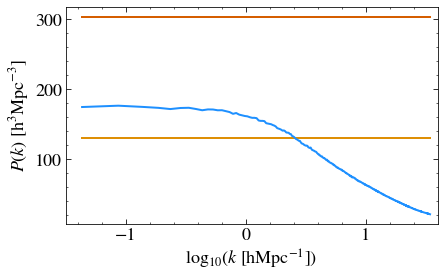

In [87]:
plt.plot(np.log10(ks), [Pk_gal10.attrs["shotnoise"]]*len(ks), c=palette_tab10[1])
plt.plot(np.log10(ks), [Pk_sum10.attrs["shotnoise"]]*len(ks), c=palette_tab10[3])
plt.plot(np.log10(ks), (Pk_gal10["power"][:iend]-(Pk_sum10["power"][:iend]-Pk_sum10.attrs["shotnoise"]))-Pk_gal10.attrs["shotnoise"],c="DodgerBlue")
plt.xlabel(r"$\mathrm{log}_{10}(k\ \mathrm{[h Mpc^{-1}]})$")

plt.ylabel(r"$ P(k)\ [\mathrm{h^3 Mpc^{-3}}]$")
plt.xlim(-1.5, 1.6)
#plt.savefig("../figures/shotnoise_transition.pdf", format="pdf", bbox_inches="tight")

In [82]:
plt.plot(np.log10(ks), (Pk_gal10["power"][:iend]-(Pk_sum10["power"][:iend]-Pk_sum10.attrs["shotnoise"])), c=palette_tab10[1:2])
plt.plot(np.log10(ks), [Pk_gal10.attrs["shotnoise"]]*len(ks))
plt.plot(np.log10(ks),[Pk_sum10.attrs["shotnoise"]]*len(ks))

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


Error in callback <function install_repl_displayhook.<locals>.post_execute at 0x7f482833d400> (for post_execute):


ValueError: RGBA sequence should have length 3 or 4

ValueError: RGBA sequence should have length 3 or 4

<Figure size 480x288 with 1 Axes>

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


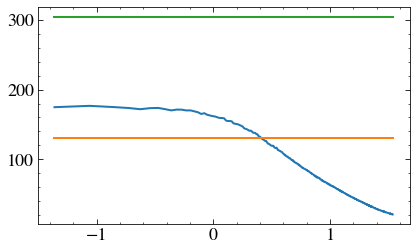

In [81]:
plt.plot(np.log10(ks), (Pk_gal10["power"][:iend]-(Pk_sum10["power"][:iend]-Pk_sum10.attrs["shotnoise"])- Pk_gal10.attrs["shotnoise"]), label="Second term (1-halo term?)")
plt.plot(np.log10(ks), [Pk_gal10.attrs["shotnoise"]]*len(ks))
plt.plot(np.log10(ks),[Pk_sum10.attrs["shotnoise"]]*len(ks))

In [41]:
tot = (Pk_gal10["power"][:iend]-(Pk_sum10["power"][:iend]-Pk_sum10.attrs["shotnoise"]))

In [42]:
shot_gal = Pk_gal10.attrs["shotnoise"]
shot_halo = Pk_sum10.attrs["shotnoise"]

In [43]:
uk = (tot - shot_gal)/(shot_halo - shot_gal)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


(-1.5, 1.5)

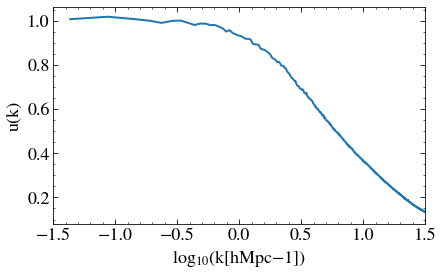

In [46]:
plt.plot(np.log10(ks), uk)
plt.ylabel("u(k)")
plt.xlabel(r"$\rm log_{10}(k [h Mpc{-1}])$")
plt.xlim(-1.5,1.5)